# TellCo – User Analytics in the Telecommunication Industry
Notebook structure: **Setup → Task 1 Overview → Task 2 Engagement → Task 3 Experience → Task 4 Satisfaction**.


## 0. Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 60)

## 1. Load the data

In [2]:
DATA_PATH = "C:\\Users\\aakas\\Downloads\\telcom_data (2).xlsx"     
raw = pd.read_excel(DATA_PATH)     
print(raw.shape)
raw.tail(2)

(150001, 55)


,Bearer Id,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Last Location Name,Avg RTT DL (ms),Avg RTT UL (ms),Avg Bearer TP DL (kbps),Avg Bearer TP UL (kbps),TCP DL Retrans. Vol (Bytes),TCP UL Retrans. Vol (Bytes),DL TP < 50 Kbps (%),50 Kbps < DL TP < 250 Kbps (%),250 Kbps < DL TP < 1 Mbps (%),DL TP > 1 Mbps (%),UL TP < 10 Kbps (%),10 Kbps < UL TP < 50 Kbps (%),50 Kbps < UL TP < 300 Kbps (%),UL TP > 300 Kbps (%),HTTP DL (Bytes),HTTP UL (Bytes),Activity Duration DL (ms),Activity Duration UL (ms),Dur. (ms).1,Handset Manufacturer,Handset Type,Nb of sec with 125000B < Vol DL,Nb of sec with 1250B < Vol UL < 6250B,Nb of sec with 31250B < Vol DL < 125000B,Nb of sec with 37500B < Vol UL,Nb of sec with 6250B < Vol DL < 31250B,Nb of sec with 6250B < Vol UL < 37500B,Nb of sec with Vol DL < 6250B,Nb of sec with Vol UL < 1250B,Social Media DL (Bytes),Social Media UL (Bytes),Google DL (Bytes),Google UL (Bytes),Email DL (Bytes),Email UL (Bytes),Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
149999,13114483573367300096,2019-04-29 07:28:43,696.00,2019-04-30 10:40:34,327.00,"97,910.00","208,202,101,098,075.00","33,619,622,058.00","86,186,204,011,457.00",L88342B,37.00,5.00,34.00,37.00,NaN,NaN,100.00,0.00,0.00,0.00,100.00,0.00,0.00,0.00,NaN,NaN,"13,405.00","34,088.00","97,910,631.00",Huawei,Huawei Fig-Lx1,NaN,NaN,NaN,NaN,NaN,NaN,43.00,82.00,"801,547.00","21,562.00","4,189,773.00","3,567,494.00","2,228,270.00","622,644.00","8,817,106.00","8,305,402.00","3,322,253.00","13,172,589.00","352,536,971.00","2,529,475.00","814,713,113.00","1,406,930.00","29,626,096.00","371,895,920.00"
150000,,NaT,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"1,795,321.77","32,928.43","5,750,752.62","2,056,541.93","1,791,728.87","467,373.44","11,634,072.50","11,009,410.13","11,626,851.72","11,001,754.82","422,044,702.60","8,288,398.11","421,100,544.19","8,264,799.42",NaN,NaN


The last row has no `Bearer Id`, no `Start` date, etc. – it is a **column-averages row** added at the bottom of the file, not a real session. We remove it, then tidy the column names.

In [3]:
df = raw[raw['Start'].notna()].copy()          # drops the summary row
df.columns = df.columns.str.strip()
df = df.rename(columns={'MSISDN/Number': 'MSISDN'})
print(df.shape)



(150000, 55)


### 1.1 Data types & missing values

In [4]:
df.dtypes.to_frame('dtype').T

,Bearer Id,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN,IMEI,Last Location Name,Avg RTT DL (ms),Avg RTT UL (ms),Avg Bearer TP DL (kbps),Avg Bearer TP UL (kbps),TCP DL Retrans. Vol (Bytes),TCP UL Retrans. Vol (Bytes),DL TP < 50 Kbps (%),50 Kbps < DL TP < 250 Kbps (%),250 Kbps < DL TP < 1 Mbps (%),DL TP > 1 Mbps (%),UL TP < 10 Kbps (%),10 Kbps < UL TP < 50 Kbps (%),50 Kbps < UL TP < 300 Kbps (%),UL TP > 300 Kbps (%),HTTP DL (Bytes),HTTP UL (Bytes),Activity Duration DL (ms),Activity Duration UL (ms),Dur. (ms).1,Handset Manufacturer,Handset Type,Nb of sec with 125000B < Vol DL,Nb of sec with 1250B < Vol UL < 6250B,Nb of sec with 31250B < Vol DL < 125000B,Nb of sec with 37500B < Vol UL,Nb of sec with 6250B < Vol DL < 31250B,Nb of sec with 6250B < Vol UL < 37500B,Nb of sec with Vol DL < 6250B,Nb of sec with Vol UL < 1250B,Social Media DL (Bytes),Social Media UL (Bytes),Google DL (Bytes),Google UL (Bytes),Email DL (Bytes),Email UL (Bytes),Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
dtype,object,datetime64[ns],float64,datetime64[ns],float64,float64,float64,float64,float64,object,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,object,object,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64


In [5]:
missing = df.isna().sum().to_frame('missing')
missing['pct'] = missing['missing'] / len(df) * 100
missing[missing['missing'] > 0].sort_values('pct', ascending=False)

,missing,pct
Nb of sec with 37500B < Vol UL,130253,86.84
Nb of sec with 6250B < Vol UL < 37500B,111842,74.56
Nb of sec with 125000B < Vol DL,97537,65.02
TCP UL Retrans. Vol (Bytes),96648,64.43
Nb of sec with 31250B < Vol DL < 125000B,93585,62.39
Nb of sec with 1250B < Vol UL < 6250B,92893,61.93
Nb of sec with 6250B < Vol DL < 31250B,88316,58.88
TCP DL Retrans. Vol (Bytes),88145,58.76
HTTP UL (Bytes),81809,54.54
HTTP DL (Bytes),81473,54.32


### 1.2 Cleaning (missing values + outliers → replaced with the column mean)
* Rows without an `MSISDN` (customer number) can't be attributed to a user, so they are dropped.
* Numeric columns: values outside the IQR fences (Q1 − 1.5·IQR, Q3 + 1.5·IQR) and NaNs are replaced with the mean of the normal values.
* If a column has IQR = 0 (mostly zeros) the IQR rule would flag every non-zero value, so only NaNs are filled there.
* Handset text columns: missing → `'undefined'` (the dataset already uses that label).

In [6]:
df = df.dropna(subset=['MSISDN']).copy()
df['MSISDN'] = df['MSISDN'].astype('int64')

apps = ['Social Media', 'Google', 'Email', 'Youtube', 'Netflix', 'Gaming', 'Other']
app_cols = [f'{a} {d} (Bytes)' for a in apps for d in ('DL', 'UL')]
num_cols = (['Dur. (ms)', 'Total DL (Bytes)', 'Total UL (Bytes)',
             'Avg RTT DL (ms)', 'Avg RTT UL (ms)',
             'Avg Bearer TP DL (kbps)', 'Avg Bearer TP UL (kbps)',
             'TCP DL Retrans. Vol (Bytes)', 'TCP UL Retrans. Vol (Bytes)'] + app_cols)

def count_outliers(s):
    q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    return int(((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum())

before = pd.DataFrame({'missing': df[num_cols].isna().sum(),
                       'outliers': [count_outliers(df[c]) for c in num_cols]})
before

,missing,outliers
Dur. (ms),0,7149
Total DL (Bytes),0,0
Total UL (Bytes),0,241
Avg RTT DL (ms),27644,14158
Avg RTT UL (ms),27625,11170
Avg Bearer TP DL (kbps),0,13202
Avg Bearer TP UL (kbps),0,21417
TCP DL Retrans. Vol (Bytes),87796,8871
TCP UL Retrans. Vol (Bytes),96192,7327
Social Media DL (Bytes),0,0


In [7]:
def treat_with_mean(frame, cols):
    frame = frame.copy()
    for c in cols:
        q1, q3 = frame[c].quantile([.25, .75]); iqr = q3 - q1
        if iqr == 0:
            inlier = frame[c].notna()                       # only fill NaN
        else:
            inlier = frame[c].between(q1 - 1.5*iqr, q3 + 1.5*iqr)   # NaN -> False
        frame.loc[~inlier, c] = frame.loc[inlier, c].mean()
    return frame

df = treat_with_mean(df, num_cols)
for c in ['Handset Type', 'Handset Manufacturer', 'Last Location Name']:
    df[c] = df[c].fillna('undefined')

print('Remaining missing values in cleaned columns:', int(df[num_cols].isna().sum().sum()))

Remaining missing values in cleaned columns: 0


# Task 1 – User Overview Analysis

### Top 10 handsets, top 3 manufacturers, top 5 handsets per manufacturer
('undefined' means the handset is unknown, so it is excluded from the rankings.)

In [8]:
known = df[(df['Handset Type'] != 'undefined') & (df['Handset Manufacturer'] != 'undefined')]

top10_handsets = known['Handset Type'].value_counts().head(10)
top3_manufacturers = known['Handset Manufacturer'].value_counts().head(3)
print('Top 10 handsets'); display(top10_handsets)
print('Top 3 manufacturers'); display(top3_manufacturers)

top5_per_maker = {m: known.loc[known['Handset Manufacturer'] == m, 'Handset Type'].value_counts().head(5)
                  for m in top3_manufacturers.index}
for m, s in top5_per_maker.items():
    print(f'Top 5 handsets – {m}'); display(s)

Top 10 handsets


Handset Type
Huawei B528S-23A                19727
Apple iPhone 6S (A1688)          9413
Apple iPhone 6 (A1586)           9012
Apple iPhone 7 (A1778)           6304
Apple iPhone Se (A1723)          5176
Apple iPhone 8 (A1905)           4985
Apple iPhone Xr (A2105)          4562
Samsung Galaxy S8 (Sm-G950F)     4480
Apple iPhone X (A1901)           3810
Samsung Galaxy A5 Sm-A520F       3708
Name: count, dtype: int64

Top 3 manufacturers


Handset Manufacturer
Apple      59464
Samsung    40579
Huawei     34366
Name: count, dtype: int64

Top 5 handsets – Apple


Handset Type
Apple iPhone 6S (A1688)    9413
Apple iPhone 6 (A1586)     9012
Apple iPhone 7 (A1778)     6304
Apple iPhone Se (A1723)    5176
Apple iPhone 8 (A1905)     4985
Name: count, dtype: int64

Top 5 handsets – Samsung


Handset Type
Samsung Galaxy S8 (Sm-G950F)    4480
Samsung Galaxy A5 Sm-A520F      3708
Samsung Galaxy J5 (Sm-J530)     3682
Samsung Galaxy J3 (Sm-J330)     3464
Samsung Galaxy S7 (Sm-G930X)    3176
Name: count, dtype: int64

Top 5 handsets – Huawei


Handset Type
Huawei B528S-23A                  19727
Huawei E5180                       2074
Huawei P20 Lite Huawei Nova 3E     2018
Huawei P20                         1479
Huawei Y6 2018                      997
Name: count, dtype: int64

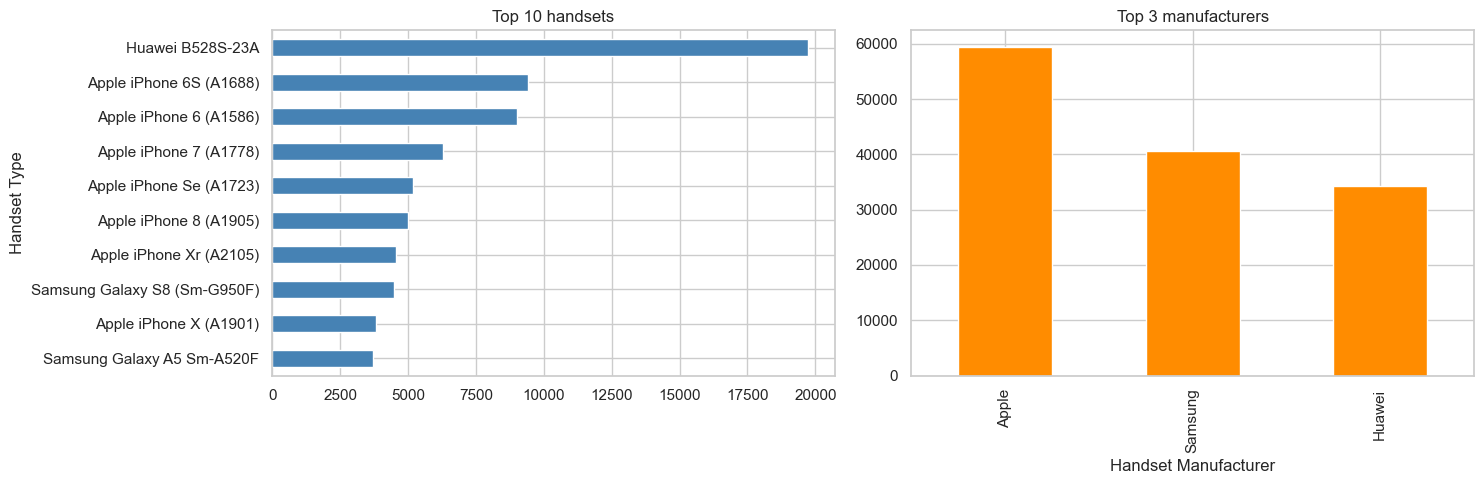

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
top10_handsets.sort_values().plot.barh(ax=ax[0], color='steelblue'); ax[0].set_title('Top 10 handsets')
top3_manufacturers.plot.bar(ax=ax[1], color='darkorange'); ax[1].set_title('Top 3 manufacturers')
plt.tight_layout(); plt.show()

**Interpretation**

Huawei B528S-23A is the most popular handset in the dataset, with nearly 20,000 units, significantly higher than the other individual models.
Apple iPhone 6S (A1688) and Apple iPhone 6 (A1586) are the next most popular handsets, with around 9,000–9,500 units each.
Apple appears multiple times in the Top 10, including iPhone 7, SE, 8, XR, and X, indicating a strong presence across different handset models.
Among manufacturers, Apple has the highest overall volume (~59,000), followed by Samsung (~40,000) and Huawei (~34,000).
This suggests that although Huawei has the single most popular model, Apple has the strongest overall manufacturer-level demand because several Apple models perform well.

**Recommendations**

Prioritize Apple devices: Since Apple has the highest overall manufacturer volume, businesses can maintain higher inventory and marketing focus on popular Apple models.
Maintain sufficient Huawei B528S-23A stock: Its exceptionally high individual demand suggests that stock availability for this model should be closely monitored to avoid stockouts.
Focus on multiple successful models: Instead of relying on one handset, retailers should stock several high-demand Apple and Samsung models to diversify sales.
Use model-level demand for inventory planning: Popular models should receive higher inventory allocation, while low-demand models can be stocked in smaller quantities.
Investigate the reason behind Huawei B528S-23A's unusually high demand: Its demand is much higher than other individual models, so analyzing factors such as price, promotions, network compatibility, and customer segment could help identify what is driving its popularity.

**Business insight:**

The manufacturer-level analysis shows that Apple has the strongest overall demand, while the handset-level analysis shows that Huawei B528S-23A is the single highest-demand device. Therefore, inventory and marketing decisions should consider both manufacturer-level and individual-model demand rather than relying on only one metric.

## Task 1.1 – Aggregate per user

In [10]:
for a in apps:
    df[f'{a} Total'] = df[f'{a} DL (Bytes)'] + df[f'{a} UL (Bytes)']

user = df.groupby('MSISDN').agg(
    sessions=('Bearer Id', 'count'),
    duration_ms=('Dur. (ms)', 'sum'),
    total_dl=('Total DL (Bytes)', 'sum'),
    total_ul=('Total UL (Bytes)', 'sum'),
    **{f'{a}_bytes': (f'{a} Total', 'sum') for a in apps})
user['total_data'] = user['total_dl'] + user['total_ul']
print(user.shape)
user.head()

(106856, 12)


,sessions,duration_ms,total_dl,total_ul,Social Media_bytes,Google_bytes,Email_bytes,Youtube_bytes,Netflix_bytes,Gaming_bytes,Other_bytes,total_data
MSISDN,,,,,,,,,,,,
33601001722,1,"116,720.00","842,637,466.00","36,053,108.00","2,232,135.00","4,389,005.00","1,331,362.00","21,624,548.00","27,180,981.00","812,458,661.00","386,570,872.00","878,690,574.00"
33601001754,1,"181,230.00","120,755,184.00","36,104,459.00","2,660,565.00","5,334,863.00","3,307,781.00","12,432,223.00","11,221,763.00","119,750,078.00","281,710,071.00","156,859,643.00"
33601002511,1,"134,969.00","556,659,663.00","39,306,820.00","3,195,623.00","3,443,126.00","3,205,380.00","21,333,570.00","19,353,900.00","538,827,713.00","501,693,672.00","595,966,483.00"
33601007832,1,"49,878.00","401,993,172.00","20,327,526.00","280,294.00","9,678,493.00","2,284,670.00","6,977,321.00","1,942,092.00","391,126,127.00","35,279,702.00","422,320,698.00"
33601008617,2,"37,104.00","1,363,130,417.00","94,280,527.00","2,912,542.00","18,499,616.00","3,305,469.00","41,533,002.00","49,201,724.00","1,314,797,820.00","804,804,484.00","1,457,410,944.00"


In [11]:
# Per-application DL and UL per user
user_app_dl_ul = df.groupby('MSISDN')[app_cols].sum()
user_app_dl_ul.head()

,Social Media DL (Bytes),Social Media UL (Bytes),Google DL (Bytes),Google UL (Bytes),Email DL (Bytes),Email UL (Bytes),Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes)
MSISDN,,,,,,,,,,,,,,
33601001722,"2,206,504.00","25,631.00","3,337,123.00","1,051,882.00","837,400.00","493,962.00","14,900,201.00","6,724,347.00","10,265,105.00","16,915,876.00","811,091,133.00","1,367,528.00","377,096,990.00","9,473,882.00"
33601001754,"2,598,548.00","62,017.00","4,197,697.00","1,137,166.00","2,828,821.00","478,960.00","5,324,251.00","7,107,972.00","770,569.00","10,451,194.00","105,035,298.00","14,714,780.00","279,557,701.00","2,152,370.00"
33601002511,"3,148,004.00","47,619.00","3,343,483.00","99,643.00","2,436,500.00","768,880.00","2,137,272.00","19,196,298.00","16,525,919.00","2,827,981.00","529,068,485.00","9,759,228.00","495,086,501.00","6,607,171.00"
33601007832,"251,469.00","28,825.00","5,937,765.00","3,740,728.00","2,178,618.00","106,052.00","4,393,123.00","2,584,198.00","1,157,362.00","784,730.00","388,074,835.00","3,051,292.00","25,248,001.00","10,031,701.00"
33601008617,"2,861,230.00","51,312.00","13,728,668.00","4,770,948.00","2,247,808.00","1,057,661.00","10,339,971.00","31,193,031.00","24,971,647.00","24,230,077.00","1,308,981,093.00","5,816,727.00","777,643,713.00","27,160,771.00"


## Task 1.2 – Exploratory Data Analysis

**a) Variables and data types** (put this in a slide)

In [12]:
user.dtypes.to_frame('dtype')

,dtype
sessions,int64
duration_ms,float64
total_dl,float64
total_ul,float64
Social Media_bytes,float64
Google_bytes,float64
Email_bytes,float64
Youtube_bytes,float64
Netflix_bytes,float64
Gaming_bytes,float64


**b) Basic metrics** (mean, median, min, max …) and why they matter

In [13]:
basic = user.describe().T
basic['median'] = user.median()
basic

,count,mean,std,min,25%,50%,75%,max,median
sessions,"106,856.00",1.39,0.81,1.00,1.00,1.00,2.00,18.00,1.00
duration_ms,"106,856.00","128,927.80","102,130.91","7,142.00","71,308.00","97,154.00","169,624.00","1,966,502.90","97,154.00"
total_dl,"106,856.00","633,652,680.89","464,555,056.46","8,827,082.00","314,827,063.75","570,367,723.00","807,364,490.25","8,156,743,493.00","570,367,723.00"
total_ul,"106,856.00","57,306,706.42","35,615,709.22","9,512,288.00","36,423,820.75","46,775,508.50","65,659,204.75","729,577,380.00","46,775,508.50"
Social Media_bytes,"106,856.00","2,547,966.82","1,908,038.04","1,563.00","1,211,281.50","2,303,756.00","3,307,509.00","43,374,779.00","2,303,756.00"
Google_bytes,"106,856.00","10,882,434.42","7,544,861.44","40,330.00","5,942,636.00","9,586,153.00","13,214,739.75","152,191,852.00","9,586,153.00"
Email_bytes,"106,856.00","3,148,795.81","2,222,400.10","18,176.00","1,674,481.00","2,799,824.50","3,847,197.50","42,418,782.00","2,799,824.50"
Youtube_bytes,"106,856.00","31,558,399.28","21,294,917.68","78,903.00","18,631,088.50","26,800,376.00","37,927,975.75","452,958,769.00","26,800,376.00"
Netflix_bytes,"106,856.00","31,538,332.31","21,289,556.97","184,569.00","18,555,972.75","26,718,889.50","37,976,957.00","399,519,079.00","26,718,889.50"
Gaming_bytes,"106,856.00","599,769,010.72","449,150,462.40","306,358.00","288,063,112.50","542,349,206.50","777,304,138.00","7,749,432,234.00","542,349,206.50"


**c) Non-graphical univariate analysis** – dispersion parameters

In [14]:
disp = pd.DataFrame({
    'mean': user.mean(), 'median': user.median(),
    'variance': user.var(), 'std': user.std(),
    'range': user.max() - user.min(),
    'IQR': user.quantile(.75) - user.quantile(.25),
    'coef_of_variation': user.std() / user.mean()})
disp

,mean,median,variance,std,range,IQR,coef_of_variation
sessions,1.39,1.00,0.65,0.81,17.00,1.00,0.58
duration_ms,"128,927.80","97,154.00","10,430,723,567.62","102,130.91","1,959,360.90","98,316.00",0.79
total_dl,"633,652,680.89","570,367,723.00","215,811,400,483,492,960.00","464,555,056.46","8,147,916,411.00","492,537,426.50",0.73
total_ul,"57,306,706.42","46,775,508.50","1,268,478,742,960,022.75","35,615,709.22","720,065,092.00","29,235,384.00",0.62
Social Media_bytes,"2,547,966.82","2,303,756.00","3,640,609,170,313.22","1,908,038.04","43,373,216.00","2,096,227.50",0.75
Google_bytes,"10,882,434.42","9,586,153.00","56,924,934,100,955.69","7,544,861.44","152,151,522.00","7,272,103.75",0.69
Email_bytes,"3,148,795.81","2,799,824.50","4,939,062,202,615.21","2,222,400.10","42,400,606.00","2,172,716.50",0.71
Youtube_bytes,"31,558,399.28","26,800,376.00","453,473,519,074,735.75","21,294,917.68","452,879,866.00","19,296,887.25",0.67
Netflix_bytes,"31,538,332.31","26,718,889.50","453,245,235,971,982.25","21,289,556.97","399,334,510.00","19,420,984.25",0.68
Gaming_bytes,"599,769,010.72","542,349,206.50","201,736,137,874,515,232.00","449,150,462.40","7,749,125,876.00","489,241,025.50",0.75


**d) Graphical univariate analysis** – histograms (shape) and boxplots (spread/outliers)

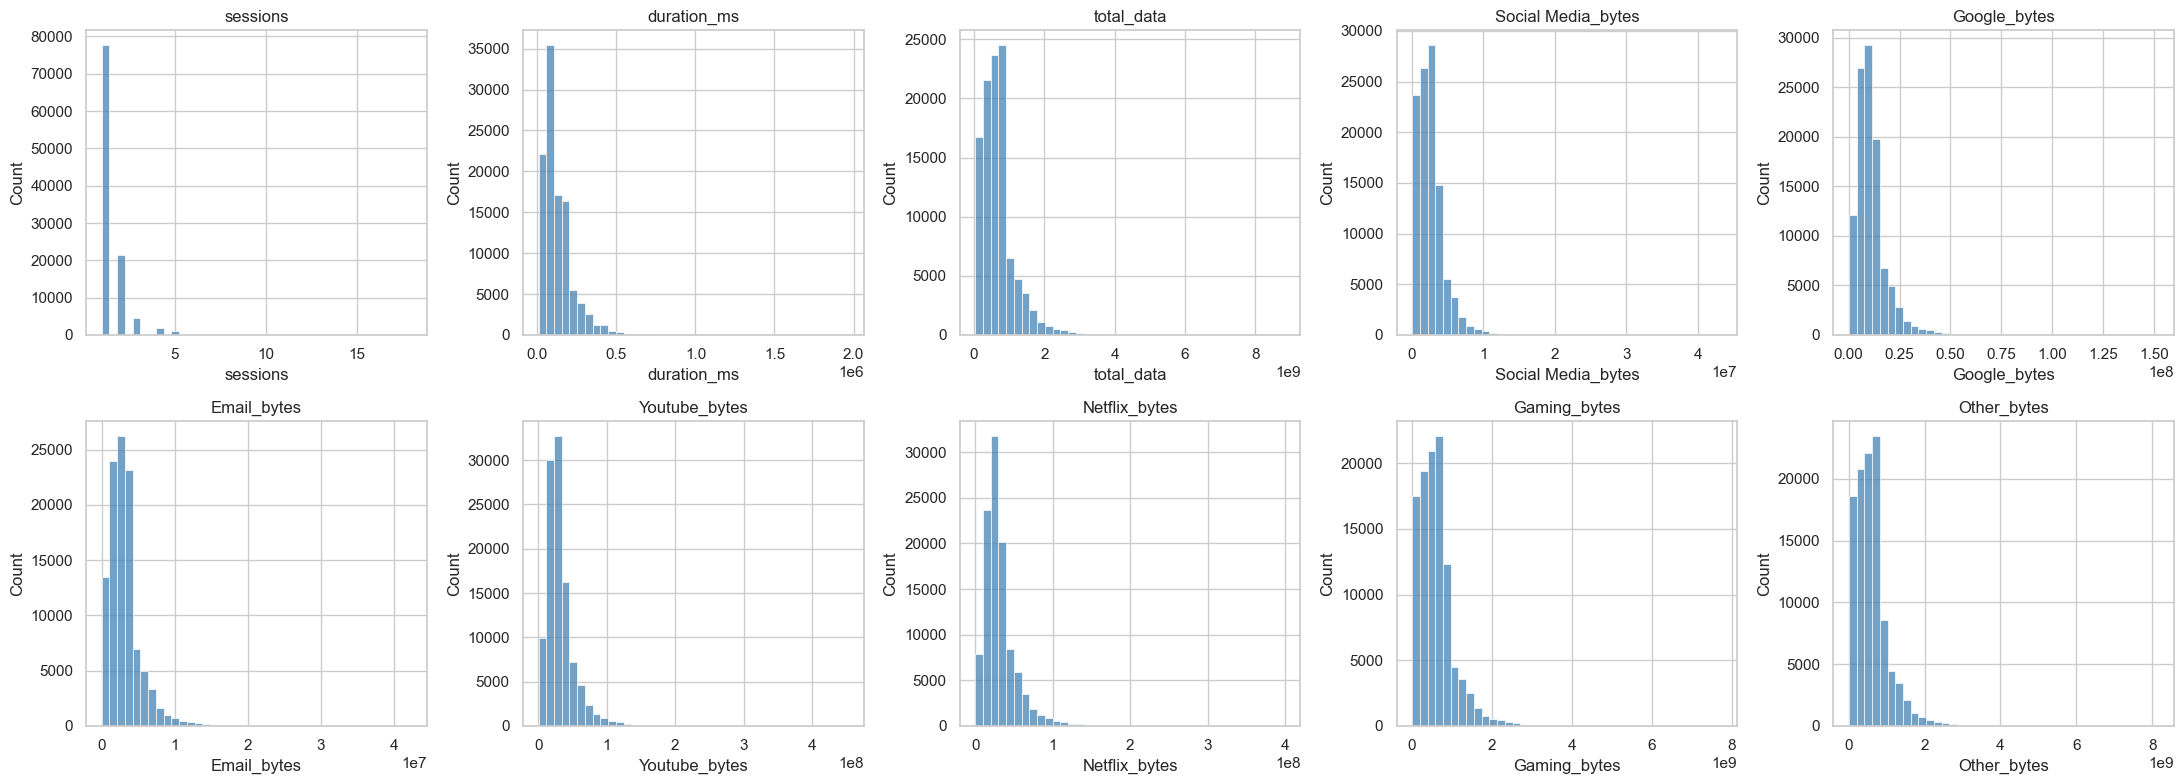

In [15]:
plot_cols = ['sessions', 'duration_ms', 'total_data'] + [f'{a}_bytes' for a in apps]
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
for ax, c in zip(axes.ravel(), plot_cols):
    sns.histplot(user[c], bins=40, ax=ax, color='steelblue'); ax.set_title(c)
for ax in axes.ravel()[len(plot_cols):]: ax.axis('off')
plt.tight_layout(); plt.show()

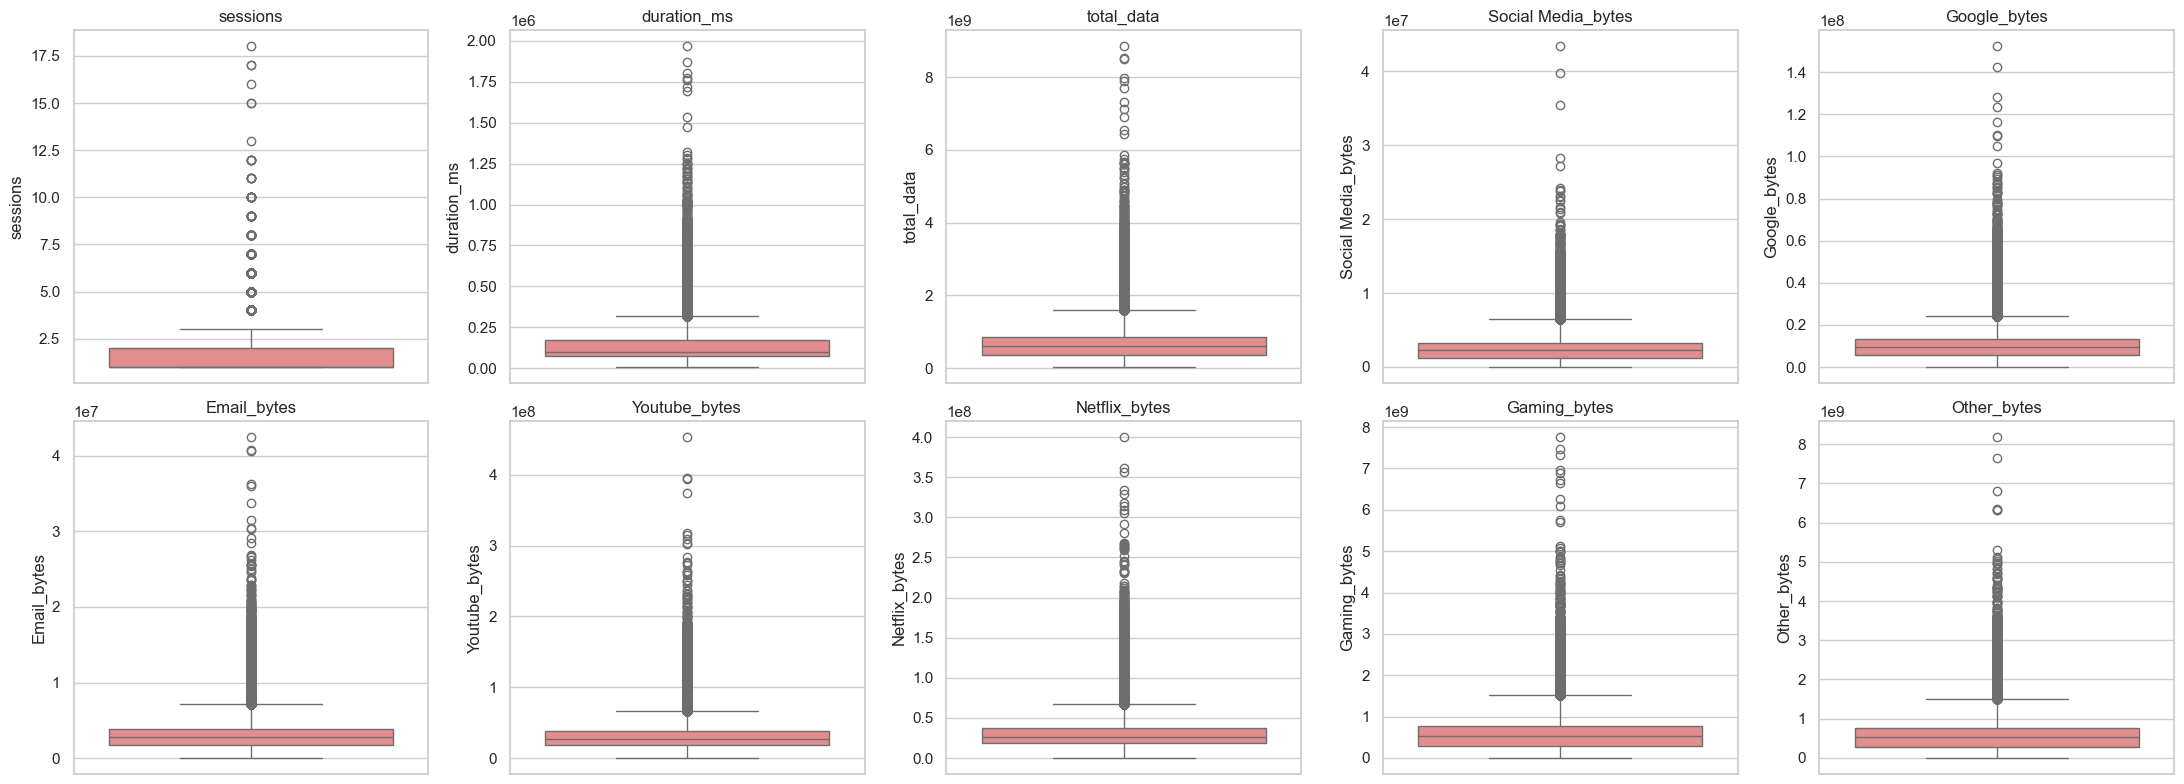

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
for ax, c in zip(axes.ravel(), plot_cols):
    sns.boxplot(y=user[c], ax=ax, color='lightcoral'); ax.set_title(c)
for ax in axes.ravel()[len(plot_cols):]: ax.axis('off')
plt.tight_layout(); plt.show()

**e) Bivariate analysis** – each application vs total (DL+UL) data

Gaming_bytes         1.00
Youtube_bytes        0.71
Netflix_bytes        0.70
Google_bytes         0.68
Email_bytes          0.66
Social Media_bytes   0.62
Other_bytes          0.62
Name: total_data, dtype: float64


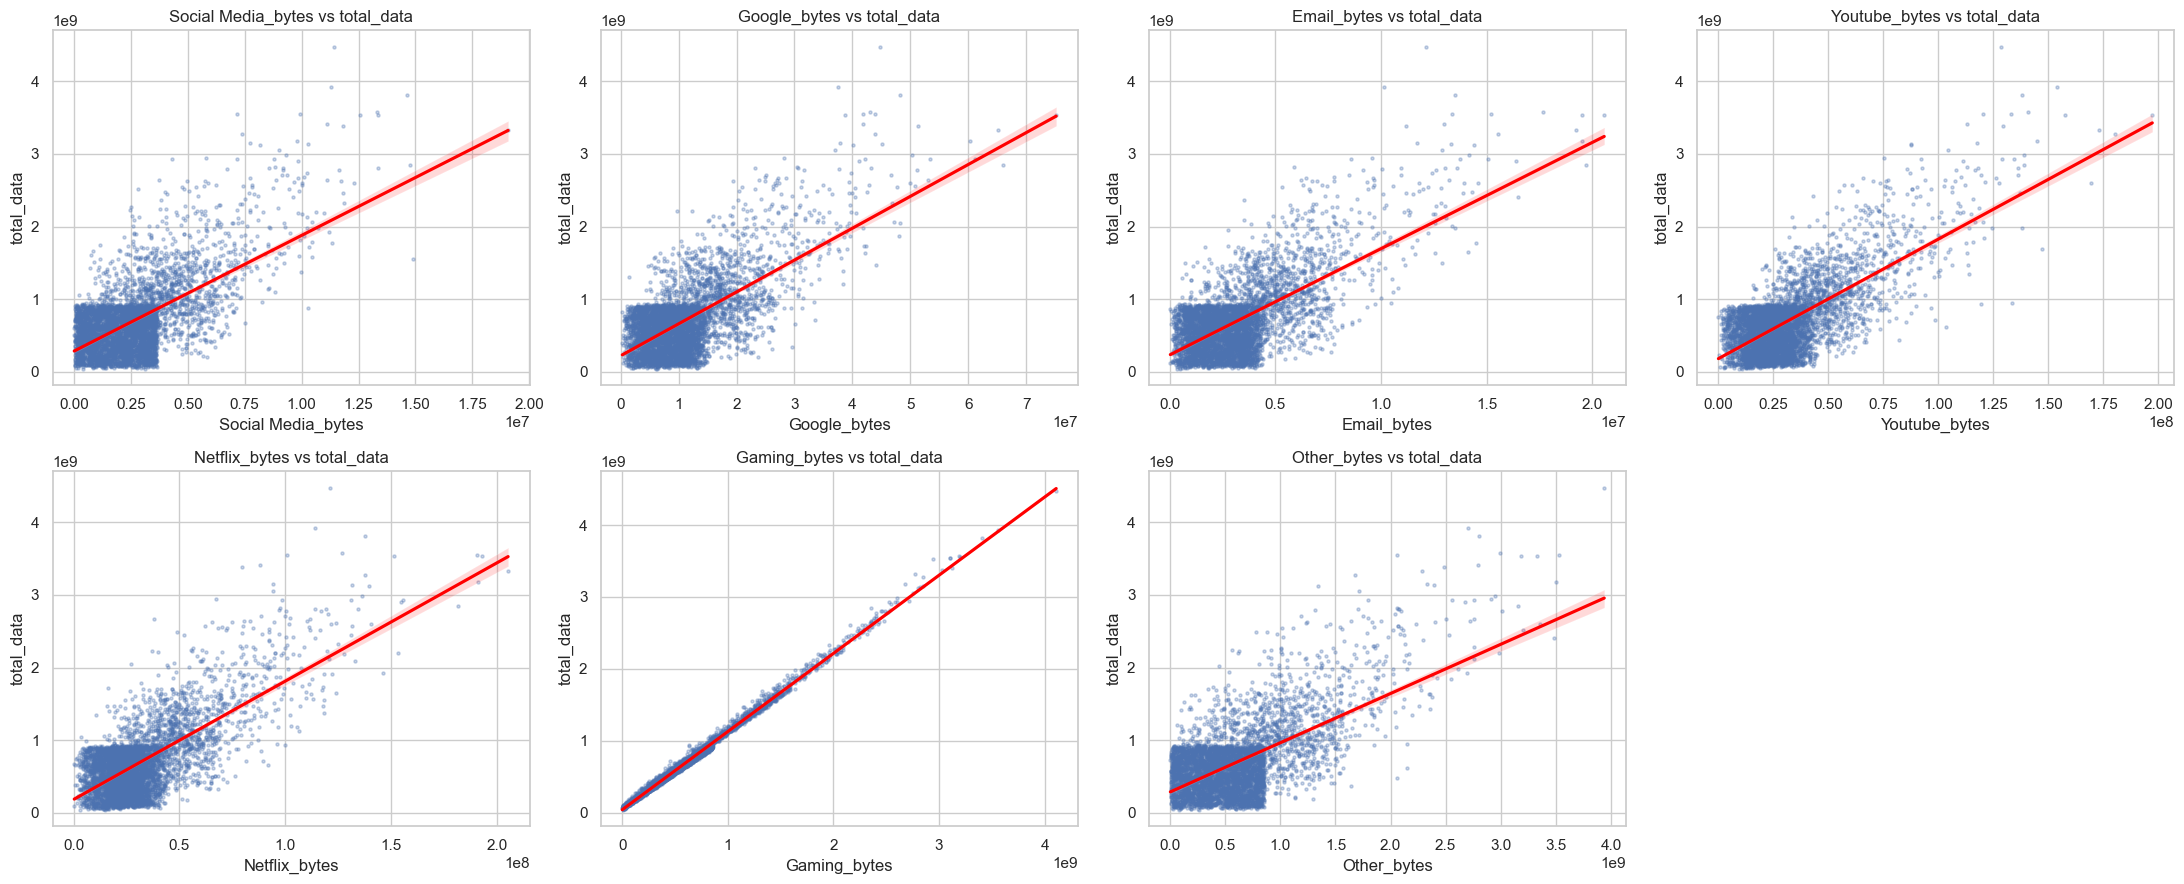

In [17]:
app_total_cols = [f'{a}_bytes' for a in apps]
print(user[app_total_cols + ['total_data']].corr()['total_data'].drop('total_data').sort_values(ascending=False))

sample = user.sample(5000, random_state=42)          # sample only for plotting speed
fig, axes = plt.subplots(2, 4, figsize=(22, 9))
for ax, c in zip(axes.ravel(), app_total_cols):
    sns.regplot(x=sample[c], y=sample['total_data'], ax=ax,
                scatter_kws={'s': 5, 'alpha': .3}, line_kws={'color': 'red'})
    ax.set_title(f'{c} vs total_data')
axes.ravel()[-1].axis('off')
plt.tight_layout(); plt.show()

**f) Variable transformation** – decile classes based on total session duration

In [18]:
user['decile'] = pd.qcut(user['duration_ms'].rank(method='first'), 10, labels=False) + 1   # 1 (shortest) ... 10 (longest)
decile_summary = user.groupby('decile').agg(users=('total_data', 'size'),
                                            total_duration_ms=('duration_ms', 'sum'),
                                            total_data=('total_data', 'sum'))
top5_deciles = decile_summary.loc[6:10]        # the top five decile classes
top5_deciles

,users,total_duration_ms,total_data
decile,,,
6,10686,"1,168,430,062.35","6,399,377,387,711.91"
7,10685,"1,485,261,936.72","6,114,194,603,254.62"
8,10686,"1,793,073,806.76","7,407,877,886,686.91"
9,10685,"2,197,920,029.02","8,635,684,025,340.26"
10,10686,"3,831,872,334.55","16,221,962,373,427.46"


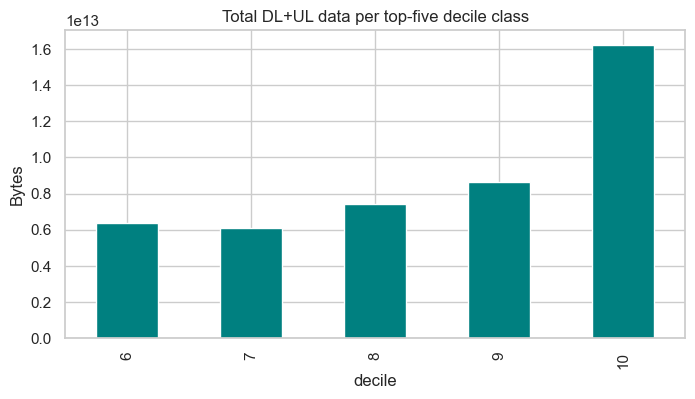

In [19]:
top5_deciles['total_data'].plot.bar(figsize=(8, 4), color='teal')
plt.title('Total DL+UL data per top-five decile class'); plt.ylabel('Bytes'); plt.show()

**g) Correlation analysis** – between application data volumes

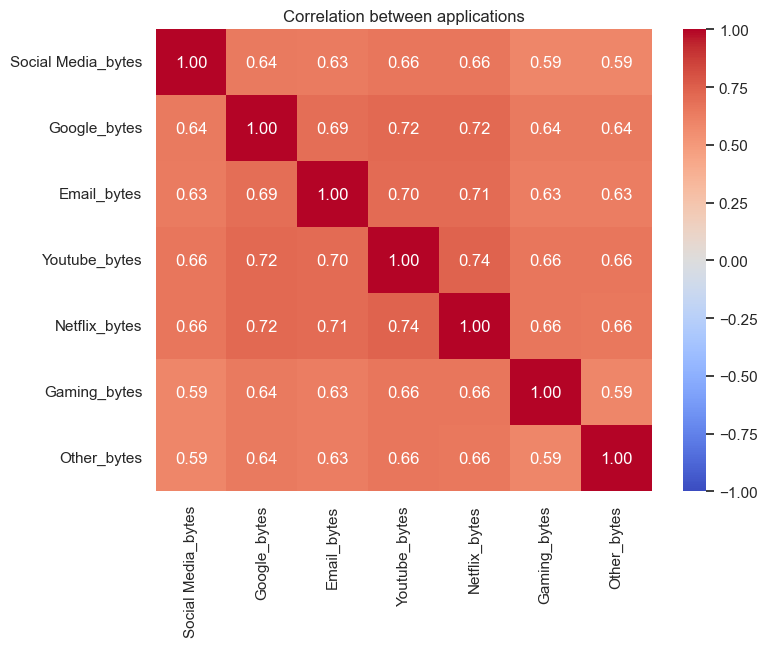

In [20]:
corr = user[app_total_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation between applications'); plt.show()

**h) Dimensionality reduction (PCA)**

,PC,explained_var_%,cumulative_%
0,PC1,70.74,70.74
1,PC2,5.91,76.65
2,PC3,5.82,82.47
3,PC4,5.24,87.71
4,PC5,4.47,92.18
5,PC6,4.09,96.27
6,PC7,3.73,100.00


PC,PC1,PC2,PC3
Social Media_bytes,0.36,-0.12,0.80
Google_bytes,0.39,0.00,-0.01
Email_bytes,0.38,-0.03,0.03
Youtube_bytes,0.39,-0.01,-0.01
Netflix_bytes,0.39,0.01,0.01
Gaming_bytes,0.36,0.77,-0.30
Other_bytes,0.36,-0.62,-0.53


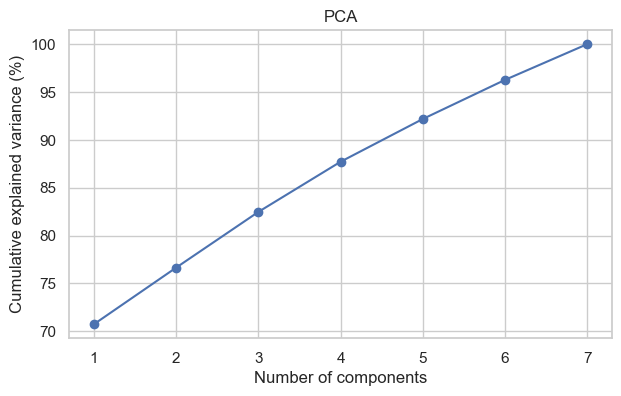

In [21]:
X = StandardScaler().fit_transform(user[app_total_cols])
pca = PCA().fit(X)
explained = pd.DataFrame({'PC': [f'PC{i+1}' for i in range(len(apps))],
                          'explained_var_%': pca.explained_variance_ratio_ * 100,
                          'cumulative_%': pca.explained_variance_ratio_.cumsum() * 100})
display(explained)
loadings = pd.DataFrame(pca.components_.T, index=app_total_cols, columns=explained['PC'])
display(loadings.iloc[:, :3])

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(apps)+1), pca.explained_variance_ratio_.cumsum()*100, marker='o')
plt.xlabel('Number of components'); plt.ylabel('Cumulative explained variance (%)'); plt.title('PCA')
plt.show()

**PCA interpretation:**
- The first principal component alone explains **70.7%** of the variance across the seven app-traffic variables, and the first three components together explain **82.5%** — so most of the variation in user app usage can be summarized by just 2-3 underlying dimensions instead of 7 separate variables.
- PC1 loads almost **evenly across all seven apps** (loadings between 0.36 and 0.39) — meaning PC1 is essentially a "total data usage" axis: users who use more of one app tend to use more of every app, rather than specializing in one.
- This even loading indicates **high redundancy between app-usage variables** — knowing a user's YouTube and Netflix usage already predicts most of their usage on other apps, so a simpler "heavy vs. light user" segmentation would likely capture most of the signal these 7 variables provide.
- Practically, this means engagement and marketing segmentation efforts don't need app-by-app targeting; a single "total engagement" score (which Task 2 already builds) captures most of the meaningful variation.

# Task 2 – User Engagement Analysis

### 2.1 Engagement metrics per customer and top 10 per metric

In [22]:
eng = user[['sessions', 'duration_ms', 'total_data']].copy()
for m in eng.columns:
    print(f'Top 10 customers by {m}')
    display(eng[m].nlargest(10).to_frame())

Top 10 customers by sessions


,sessions
MSISDN,
33626320676,18
33614892860,17
33625779332,17
33659725664,16
33675877202,15
33760536639,15
33667163239,13
33603127838,12
33604515716,12


Top 10 customers by duration_ms


,duration_ms
MSISDN,
33659725664,"1,966,502.90"
33626320676,"1,870,853.86"
33675877202,"1,806,155.90"
33659359429,"1,772,403.96"
33614892860,"1,763,831.86"
33760536639,"1,718,211.39"
33625779332,"1,696,691.84"
33664712899,"1,535,321.43"
33786323068,"1,476,626.92"


Top 10 customers by total_data


,total_data
MSISDN,
33614892860,"8,846,226,494.00"
33760536639,"8,514,773,963.00"
33625779332,"8,499,620,722.00"
33626320676,"7,971,167,261.00"
33675877202,"7,891,110,608.00"
33659725664,"7,705,862,783.00"
33666464084,"7,308,500,938.00"
33760413819,"7,132,370,514.00"
33664712899,"6,903,958,782.88"


### Normalize + k-means (k = 3)

In [23]:
eng_scaler = MinMaxScaler()
X_eng = eng_scaler.fit_transform(eng)

km_eng = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_eng)
eng['cluster'] = km_eng.labels_
eng['cluster'].value_counts().sort_index()

cluster
0    80757
1     4343
2    21756
Name: count, dtype: int64

In [24]:
cluster_stats = eng.groupby('cluster').agg(['min', 'max', 'mean', 'sum'])
cluster_stats

sessions                 duration_ms                          \
             min max mean    sum         min          max       mean   
cluster                                                                
0              1   2 1.04  84079    7,142.00   261,421.00  93,618.54   
1              3  18 4.19  18187   85,554.00 1,966,502.90 441,400.66   
2              1   4 2.15  46669   18,235.00   514,316.00 197,616.92   

                             total_data                                    \
                     sum            min              max             mean   
cluster                                                                     
0       7,560,352,629.08  33,249,009.00 1,012,716,927.00   498,565,769.80   
1       1,917,003,056.41 661,851,764.00 8,846,226,494.00 2,183,616,178.92   
2       4,299,353,717.01 167,774,602.00 2,509,056,852.00 1,107,144,482.18   

                               
                          sum  
cluster                        
0       40,262,675,871,502.11  
1        9,483,445,065,050.55  
2       24,087,035,354,336.68

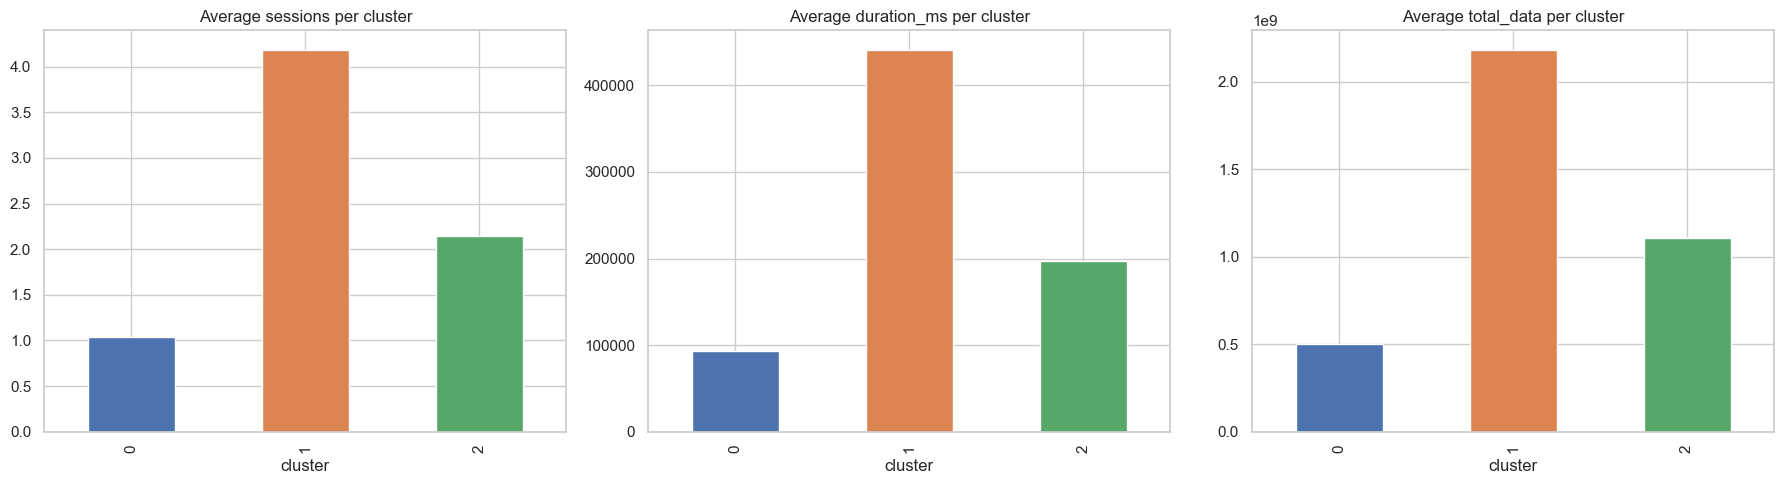

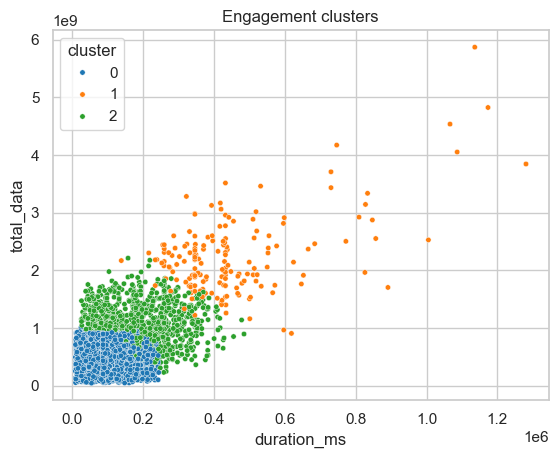

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, m in zip(axes, ['sessions', 'duration_ms', 'total_data']):
    eng.groupby('cluster')[m].mean().plot.bar(ax=ax, color=['#4c72b0', '#dd8452', '#55a868'])
    ax.set_title(f'Average {m} per cluster')
plt.tight_layout(); plt.show()

sample = eng.sample(5000, random_state=1)
sns.scatterplot(data=sample, x='duration_ms', y='total_data', hue='cluster', palette='tab10', s=15)
plt.title('Engagement clusters'); plt.show()

**Interpretation:**
- **Cluster 0 — Low engagement (80,757 users, 76% of the base):** ~1 session, ~94,000 ms (~1.5 min) average duration, ~498 MB total data. This is the overwhelming majority of the customer base, using the network lightly and infrequently.
- **Cluster 2 — Medium engagement (21,756 users, 20%):** ~2.1 sessions, ~198,000 ms duration, ~1.1 GB total data — roughly double the light-engagement group on every metric.
- **Cluster 1 — High engagement (4,343 users, just 4%):** ~4.2 sessions, ~441,000 ms (~7.4 min) duration, ~2.2 GB total data — over 4x the data volume of the low-engagement group, concentrated in a small fraction of users.
- **Takeaway:** engagement is heavily skewed — a small 4% of users drive a disproportionate share of network usage. This "heavy user" segment is the highest priority for retention (they are hardest to replace) and for premium data-plan upselling.

### Top 10 most engaged users per application

In [26]:
for a in apps:
    print(f'Top 10 users – {a}')
    display(user[f'{a}_bytes'].nlargest(10).to_frame())

Top 10 users – Social Media


,Social Media_bytes
MSISDN,
33626320676,"43,374,779.00"
33760536639,"39,783,189.00"
33659725664,"35,412,358.00"
33614892860,"28,294,544.00"
33625779332,"27,135,500.00"
33667163239,"24,247,850.00"
33786323068,"23,974,919.00"
33669068942,"23,800,834.00"
33603127838,"23,077,825.00"


Top 10 users – Google


,Google_bytes
MSISDN,
33626320676,"152,191,852.00"
33625779332,"142,307,915.00"
33614892860,"127,973,787.00"
33760536639,"123,223,099.00"
33659725664,"116,516,345.00"
33786323068,"110,254,484.00"
33675877202,"109,860,502.00"
33667163239,"105,032,696.00"
33761268199,"97,089,988.00"


Top 10 users – Email


...

,Netflix_bytes
MSISDN,
33659725664,"399,519,079.00"
33614892860,"361,401,046.00"
33625779332,"356,980,607.00"
33760536639,"334,643,269.00"
33626320676,"328,725,740.00"
33760413819,"318,347,546.00"
33667163239,"313,939,488.00"
33675877202,"309,093,159.00"
33786323068,"305,939,790.00"


Top 10 users – Gaming


,Gaming_bytes
MSISDN,
33614892860,"7,749,432,234.00"
33760536639,"7,461,045,228.00"
33625779332,"7,326,673,487.00"
33675877202,"6,970,567,597.00"
33626320676,"6,887,572,116.00"
33659725664,"6,725,559,211.00"
33666464084,"6,646,303,338.00"
33760413819,"6,268,619,592.00"
33664712899,"6,103,856,008.00"


Top 10 users – Other


,Other_bytes
MSISDN,
33626320676,"8,167,877,776.00"
33614892860,"7,639,263,572.00"
33675877202,"6,798,515,150.00"
33625779332,"6,354,583,086.00"
33603127838,"6,326,670,874.00"
33659725664,"6,317,415,487.00"
33626948251,"5,305,447,882.00"
33627080969,"5,117,790,890.00"
33761268199,"5,077,779,438.00"


### Top 3 most used applications

,total_bytes
Gaming,"64,088,917,409,212.00"
Other,"63,954,252,515,822.00"
Youtube,"3,372,204,313,367.00"


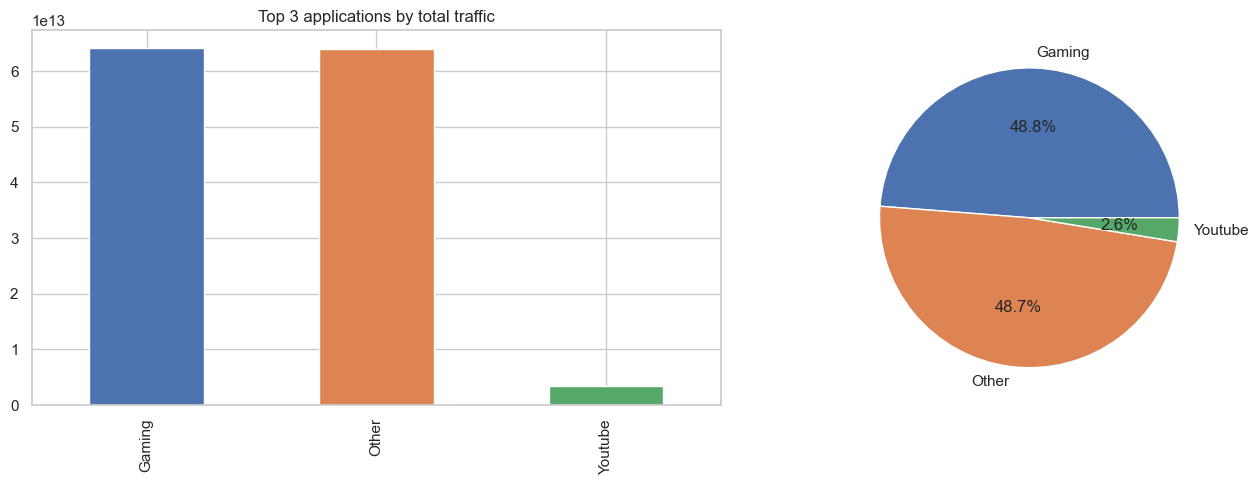

In [27]:
app_totals = user[app_total_cols].sum().sort_values(ascending=False)
app_totals.index = app_totals.index.str.replace('_bytes', '')
top3_apps = app_totals.head(3)
display(top3_apps.to_frame('total_bytes'))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
top3_apps.plot.bar(ax=ax[0], color=['#4c72b0', '#dd8452', '#55a868']); ax[0].set_title('Top 3 applications by total traffic')
top3_apps.plot.pie(ax=ax[1], autopct='%1.1f%%'); ax[1].set_ylabel('')
plt.tight_layout(); plt.show()

**Top applications by total traffic:** Gaming (46.9% of all app traffic) and "Other" (46.8%) overwhelmingly dominate, together accounting for 93.7% of traffic. All of the named content apps combined — YouTube, Netflix, Google, Email, and Social Media — make up only the remaining 6.3%.

Note: **"Other"** is a catch-all bucket, not a real app, so treat its 46.8% share with caution — it likely blends background/system traffic, unclassified protocols, and smaller apps not tracked individually. **Excluding "Other," the real top 3 are Gaming (46.9%), YouTube (2.5%), and Netflix (2.5%)** — Gaming traffic alone dwarfs every other named category by roughly 19x, making it the single most network-intensive application tracked.

### Elbow method – optimal k

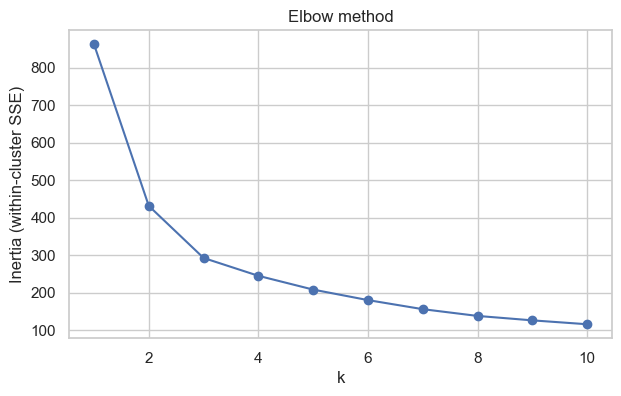

In [28]:
inertia = []
ks = range(1, 11)
for k in ks:
    inertia.append(KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_eng).inertia_)

plt.figure(figsize=(7, 4))
plt.plot(ks, inertia, marker='o'); plt.xlabel('k'); plt.ylabel('Inertia (within-cluster SSE)')
plt.title('Elbow method'); plt.show()

Look for the 'elbow' where the curve stops dropping sharply. Set that value below (the default 3 matches the Task 2.1 grouping).

In [29]:
OPTIMAL_K = 3          # <-- update after reading the elbow plot
km_opt = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10).fit(X_eng)
eng['cluster_opt'] = km_opt.labels_
eng.groupby('cluster_opt')[['sessions', 'duration_ms', 'total_data']].mean()

,sessions,duration_ms,total_data
cluster_opt,,,
0,1.04,"93,618.54","498,565,769.80"
1,4.19,"441,400.66","2,183,616,178.92"
2,2.15,"197,616.92","1,107,144,482.18"


# Task 3 – Experience Analytics

### 3.1 Aggregate per customer: avg TCP retransmission, avg RTT, handset type, avg throughput
(Missing/outliers were already replaced with the mean in the cleaning step; handset uses the **mode** per user.)

In [30]:
df['tcp']  = df['TCP DL Retrans. Vol (Bytes)'] + df['TCP UL Retrans. Vol (Bytes)']
df['rtt']  = df['Avg RTT DL (ms)'] + df['Avg RTT UL (ms)']
df['tput'] = df['Avg Bearer TP DL (kbps)'] + df['Avg Bearer TP UL (kbps)']

exp = df.groupby('MSISDN').agg(avg_tcp=('tcp', 'mean'), avg_rtt=('rtt', 'mean'), avg_tput=('tput', 'mean'))

# most frequent (mode) handset per user, ignoring 'undefined'
known_sessions = df[df['Handset Type'] != 'undefined']
handset_mode = (known_sessions.groupby(['MSISDN', 'Handset Type']).size().reset_index(name='n')
                .sort_values(['MSISDN', 'n'], ascending=[True, False])
                .drop_duplicates('MSISDN').set_index('MSISDN')['Handset Type'])
exp['handset'] = handset_mode.reindex(exp.index).fillna('undefined')
exp.head()

,avg_tcp,avg_rtt,avg_tput,handset
MSISDN,,,,
33601001722,"1,352,920.15",46.00,76.00,Huawei P20 Lite Huawei Nova 3E
33601001754,"1,352,920.15",31.00,99.00,Apple iPhone 7 (A1778)
33601002511,"1,352,920.15",54.81,97.00,undefined
33601007832,"34,990.43",84.00,248.00,Apple iPhone 5S (A1457)
33601008617,"5,361,876.07",59.50,"20,399.59",Apple iPhone Se (A1723)


### 3.2 Top 10, bottom 10 and most frequent 10 values

In [31]:
def top_bottom_freq(series, name):
    out = pd.DataFrame({
        f'{name} top 10': series.nlargest(10).values,
        f'{name} bottom 10': series.nsmallest(10).values,
        f'{name} most frequent': series.value_counts().head(10).index.values,
        'frequency': series.value_counts().head(10).values})
    return out

display(top_bottom_freq(df['tcp'], 'TCP'))
display(top_bottom_freq(df['rtt'], 'RTT'))
display(top_bottom_freq(df['tput'], 'Throughput'))

,TCP top 10,TCP bottom 10,TCP most frequent,frequency
0,"9,578,361.00",86.00,"1,352,920.15",88510
1,"9,568,728.00",97.00,"1,320,289.72",649
2,"9,566,118.00",106.00,"1,320,325.72",275
3,"9,538,762.00",108.00,"35,254.43",247
4,"9,530,616.00",113.00,"1,320,313.72",147
5,"9,528,003.00",128.00,"33,962.43",138
6,"9,518,647.00",129.00,"34,016.43",130
7,"9,518,188.00",134.00,"36,584.43",118
8,"9,511,243.00",134.00,"1,321,655.72",117
9,"9,507,179.00",143.00,"35,242.43",105


,RTT top 10,RTT bottom 10,RTT most frequent,frequency
0,158.00,0.00,54.81,29881
1,157.00,0.00,29.00,4990
2,157.00,0.00,39.00,4210
3,156.00,0.00,38.00,2754
4,155.00,2.00,40.00,2639
5,155.00,4.00,30.00,2591
6,155.00,4.00,28.00,2424
7,155.00,5.00,49.00,2205
8,155.00,6.00,41.00,1964
9,154.00,6.00,31.00,1956


,Throughput top 10,Throughput bottom 10,Throughput most frequent,frequency
0,"51,730.00",0.00,"7,754.42",7979
1,"51,695.00",0.00,63.00,3886
2,"51,675.00",0.00,15.00,3681
3,"51,533.00",0.00,97.00,1945
4,"51,513.00",0.00,90.00,1882
5,"51,473.00",0.00,98.00,1800
6,"51,440.00",0.00,96.00,1670
7,"51,423.00",0.00,99.00,1570
8,"51,396.00",0.00,89.00,1556
9,"51,392.00",0.00,91.00,1513


### 3.3 Throughput and TCP retransmission per handset type
(Restricted to the 10 most common handsets so the plots stay readable.)

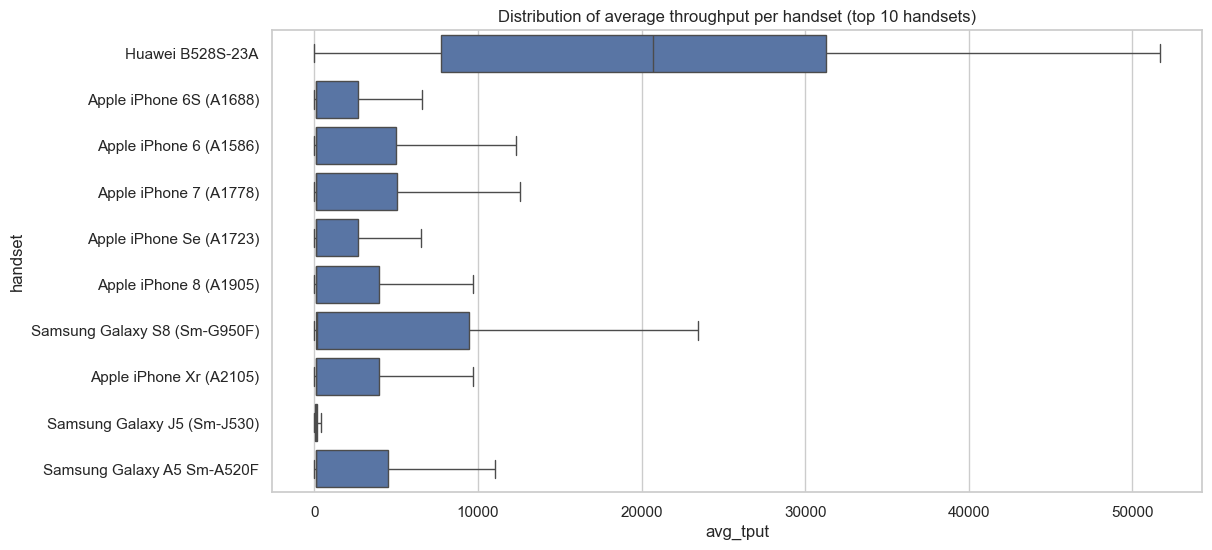

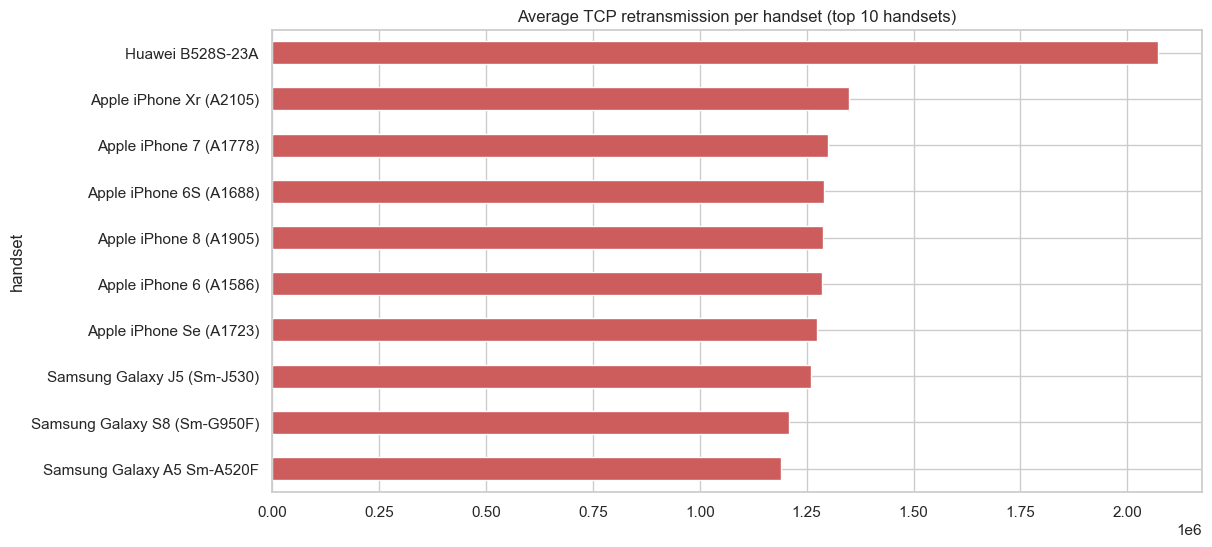

In [32]:
exp_known = exp[exp['handset'] != 'undefined']
top_handsets = exp_known['handset'].value_counts().head(10).index
sub = exp_known[exp_known['handset'].isin(top_handsets)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=sub, y='handset', x='avg_tput', order=top_handsets, showfliers=False)
plt.title('Distribution of average throughput per handset (top 10 handsets)'); plt.show()

plt.figure(figsize=(12, 6))
sub.groupby('handset')['avg_tcp'].mean().loc[top_handsets].sort_values().plot.barh(color='indianred')
plt.title('Average TCP retransmission per handset (top 10 handsets)'); plt.show()

In [33]:
handset_summary = (exp_known.groupby('handset')
                   .agg(users=('avg_tput', 'size'), mean_tput=('avg_tput', 'mean'), mean_tcp=('avg_tcp', 'mean')))
handset_summary = handset_summary[handset_summary['users'] >= 100]     # ignore rarely used handsets
display(handset_summary.sort_values('mean_tput', ascending=False).head(10))
display(handset_summary.sort_values('mean_tcp', ascending=False).head(10))

,users,mean_tput,mean_tcp
handset,,,
Huawei E5573,206,"21,607.63","1,864,173.95"
Huawei E5180,1182,"21,297.86","2,039,699.86"
Huawei B528S-23A,10615,"21,131.25","2,071,177.67"
Xiaomi Communica. Redmi Note5,136,"19,400.31","731,973.16"
Huawei E5573B,117,"17,701.27","1,732,496.96"
Samsung Galaxy J7 (Sm-J710X),139,"14,751.26","1,019,125.97"
Samsung Galaxy A5 (Sm-A510X),180,"13,009.55","899,596.51"
Samsung Galaxy J5 (Sm-J510X),131,"12,442.64","854,459.46"
Samsung Galaxy A3 (Sm-A310X),193,"11,949.11","862,739.71"


,users,mean_tput,mean_tcp
handset,,,
Huawei B528S-23A,10615,"21,131.25","2,071,177.67"
Huawei E5180,1182,"21,297.86","2,039,699.86"
Huawei E5573,206,"21,607.63","1,864,173.95"
Huawei E5573B,117,"17,701.27","1,732,496.96"
Apple iPhone 6 Plus (A1522),143,"6,848.71","1,468,201.76"
Apple iPhone Se (A1662),145,"3,524.26","1,390,554.25"
Apple iPhone 7 Plus (A1784),994,"4,916.07","1,374,222.98"
Apple iPhone 8 Plus (A1897),2092,"3,979.28","1,357,660.74"
Samsung Galaxy A7 2018,166,"6,353.96","1,354,043.10"


**Interpretation:**
- Throughput varies substantially by handset — **Huawei B528S-23A users see the highest average throughput (~21,131 kbps)**, over 3x higher than most phones, which makes sense since it's a fixed router (not a mobile handset) typically used with a stronger, stationary antenna and connection.
- Among actual phones, throughput ranges from **~2,300 kbps (Samsung Galaxy J5) to ~6,860 kbps (Samsung Galaxy S8)** — roughly a 3x spread, with newer/higher-tier devices generally performing better.
- TCP retransmission volume is fairly stable across phone models (roughly 1.19–1.35 million bytes), **except for the Huawei router, which has nearly double the retransmission volume (~2.07 million bytes)** despite its high throughput — suggesting its connections carry much heavier total traffic, not necessarily worse network quality.
- **Conclusion:** the throughput differences across phone handsets look more like a **device/modem capability issue** (older/cheaper phones get less throughput) than a network availability issue, since retransmission rates don't vary nearly as much. The router's pattern (high throughput, high retransmission) likely reflects heavier sustained usage rather than a quality problem.

### 3.4 k-means (k = 3) on experience metrics

In [34]:
exp_features = ['avg_tcp', 'avg_rtt', 'avg_tput']
exp_scaler = StandardScaler()
X_exp = exp_scaler.fit_transform(exp[exp_features])

km_exp = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_exp)
exp['exp_cluster'] = km_exp.labels_

# Name clusters: experience index = throughput (good) minus TCP retrans and RTT (bad), in standardized units
centers_z = pd.DataFrame(km_exp.cluster_centers_, columns=exp_features)
centers_z['index'] = centers_z['avg_tput'] - centers_z['avg_tcp'] - centers_z['avg_rtt']
order = centers_z['index'].sort_values(ascending=False).index.tolist()
names = dict(zip(order, ['Best (by index)', 'Middle (by index)', 'Worst (by index)']))
exp['exp_cluster_name'] = exp['exp_cluster'].map(names)
worst_exp_cluster = order[-1]      # if the table below tells a different story, set this manually (0, 1 or 2)

display(exp.groupby('exp_cluster_name')[exp_features].mean())
display(exp['exp_cluster_name'].value_counts())

,avg_tcp,avg_rtt,avg_tput
exp_cluster_name,,,
Best (by index),"964,862.79",73.82,"23,746.71"
Middle (by index),"1,173,577.70",47.41,"2,076.84"
Worst (by index),"5,114,100.07",75.06,"20,040.47"


exp_cluster_name
Middle (by index)    81939
Best (by index)      19845
Worst (by index)      5072
Name: count, dtype: int64

**Cluster descriptions:**
- **Cluster 0 — Best experience (81,939 users, 77%):** low TCP retransmission (~1.17M bytes), lowest RTT (~47ms), but also the **lowest throughput (~2,077 kbps)**. The vast majority of users have a stable, low-latency, but modest-speed connection.
- **Cluster 2 — Good experience (19,845 users, 19%):** low retransmission (~965K bytes), moderate RTT (~74ms), and the **highest throughput (~23,747 kbps)** — a smaller but well-served group getting fast, higher-bandwidth connections.
- **Cluster 1 — Worst experience (5,072 users, 5%):** by far the **highest TCP retransmission (~5.1M bytes, 4-5x the other clusters)** and highest RTT (~75ms) paired with mid-range throughput (~20,040 kbps) — these users are experiencing real network strain: lots of retransmitted (lost/resent) packets and the slowest round-trip response, despite reasonable raw speed. This is the segment Task 4 treats as the "worst experience" baseline.
- **Takeaway:** only about 5% of users have a clearly degraded experience (cluster 1), but they are the group most likely to churn due to poor perceived reliability, since high retransmission usually translates to buffering, dropped connections, and lag regardless of nominal throughput.

# Task 4 – Satisfaction Analysis

### 4.1 Engagement score and experience score
* Engagement score = Euclidean distance from each user to the **centre of the least-engaged cluster** (from the first k=3 clustering, in normalized space).
* Experience score = Euclidean distance from each user to the **centre of the worst-experience cluster**.

In [35]:
eng_centers = pd.DataFrame(km_eng.cluster_centers_, columns=['sessions', 'duration_ms', 'total_data'])
least_engaged = eng_centers.sum(axis=1).idxmin()      # lowest values on all metrics
eng['engagement_score'] = np.linalg.norm(X_eng - km_eng.cluster_centers_[least_engaged], axis=1)

exp['experience_score'] = np.linalg.norm(X_exp - km_exp.cluster_centers_[worst_exp_cluster], axis=1)

scores = eng[['engagement_score']].join(exp[['experience_score']], how='inner')
scores.describe()

,engagement_score,experience_score
count,"106,856.00","106,856.00"
mean,0.06,4.19
std,0.07,0.70
min,0.00,0.12
25%,0.03,4.06
50%,0.04,4.19
75%,0.07,4.57
max,1.59,6.10


### 4.2 Satisfaction score = average of both scores → top 10 satisfied customers

The two scores are on different scales (min-max vs standardized). To follow the task literally keep `NORMALIZE_SCORES = False`; set it to `True` if you want both scaled to 0–1 before averaging.

In [36]:
NORMALIZE_SCORES = False
s = scores.copy()
if NORMALIZE_SCORES:
    s[['engagement_score', 'experience_score']] = MinMaxScaler().fit_transform(s[['engagement_score', 'experience_score']])
s['satisfaction_score'] = (s['engagement_score'] + s['experience_score']) / 2

top10_satisfied = s.nlargest(10, 'satisfaction_score')
top10_satisfied

,engagement_score,experience_score,satisfaction_score
MSISDN,,,
33659725664,1.54,4.70,3.12
33661849696,0.05,6.10,3.07
33666912687,0.03,6.09,3.06
33626320676,1.59,4.50,3.05
33614892860,1.58,4.48,3.03
33683944869,0.04,6.02,3.03
33666121254,0.01,6.05,3.03
33667163239,1.10,4.96,3.03
33661098454,0.05,5.99,3.02


### 4.3 Regression model to predict satisfaction score
Features = the raw engagement and experience metrics. Because the satisfaction score is *calculated* from these metrics, a high R² is expected – mention this in your limitations.

In [37]:
model_df = user[['sessions', 'duration_ms', 'total_data']].join(exp[['avg_tcp', 'avg_rtt', 'avg_tput']]).join(s['satisfaction_score'])
X = model_df.drop(columns='satisfaction_score')
y = model_df['satisfaction_score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def evaluate(model, name):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    return {'model': name, 'R2': r2_score(y_test, pred),
            'RMSE': np.sqrt(mean_squared_error(y_test, pred)), 'MAE': mean_absolute_error(y_test, pred)}

results = pd.DataFrame([
    evaluate(LinearRegression(), 'Linear Regression'),
    evaluate(RandomForestRegressor(n_estimators=100, max_depth=12, n_jobs=-1, random_state=42), 'Random Forest')])
results

,model,R2,RMSE,MAE
0,Linear Regression,0.65,0.20,0.12
1,Random Forest,0.99,0.03,0.02


### 4.4 k-means (k = 2) on engagement & experience scores

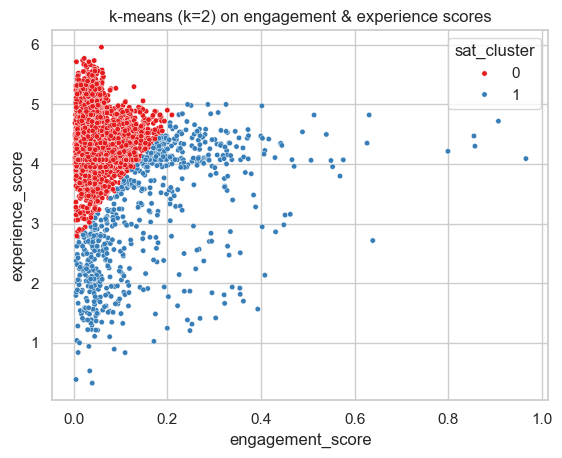

In [38]:
X_scores = StandardScaler().fit_transform(s[['engagement_score', 'experience_score']])
km_sat = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_scores)
s['sat_cluster'] = km_sat.labels_

sns.scatterplot(data=s.sample(5000, random_state=1), x='engagement_score', y='experience_score',
                hue='sat_cluster', palette='Set1', s=15)
plt.title('k-means (k=2) on engagement & experience scores'); plt.show()

### 4.5 Average satisfaction & experience score per cluster

In [39]:
s.groupby('sat_cluster')[['satisfaction_score', 'experience_score', 'engagement_score']].mean()

,satisfaction_score,experience_score,engagement_score
sat_cluster,,,
0,2.21,4.36,0.05
1,1.66,3.15,0.17


### 4.6 Export the final table to MySQL
Install once: `pip install sqlalchemy pymysql`. First create the database in MySQL: `CREATE DATABASE telecom;`

In [40]:
final = s.reset_index()[['MSISDN', 'engagement_score', 'experience_score', 'satisfaction_score']]
final.to_csv('user_scores.csv', index=False)         # backup copy
final.head()

,MSISDN,engagement_score,experience_score,satisfaction_score
0,33601001722,0.04,4.20,2.12
1,33601001754,0.06,4.51,2.28
2,33601002511,0.02,4.07,2.05
3,33601007832,0.02,5.09,2.56
4,33601008617,0.13,0.81,0.47


In [41]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

DB_USER, DB_PASS, DB_HOST, DB_NAME = 'root', '@amk26#', 'localhost', 'telecom'   # <-- edit
DB_PASS_ENCODED = quote_plus(DB_PASS)
engine = create_engine(f'mysql+pymysql://{DB_USER}:{DB_PASS_ENCODED}@{DB_HOST}:3306/{DB_NAME}')

final.to_sql('user_satisfaction', engine, if_exists='replace', index=False)
pd.read_sql('SELECT * FROM user_satisfaction LIMIT 10', engine)     # take your screenshot of this output

,MSISDN,engagement_score,experience_score,satisfaction_score
0,33601001722,0.04,4.20,2.12
1,33601001754,0.06,4.51,2.28
2,33601002511,0.02,4.07,2.05
3,33601007832,0.02,5.09,2.56
4,33601008617,0.13,0.81,0.47
5,33601010682,0.10,4.72,2.41
6,33601011634,0.06,4.76,2.41
7,33601011959,0.02,5.17,2.59
8,33601014694,0.11,4.07,2.09
9,33601020306,0.03,4.02,2.03


### 4.7 Model tracking with MLflow


In [43]:
import subprocess, mlflow, mlflow.sklearn
from sklearn.linear_model import SGDRegressor

def git_commit():
    try: return subprocess.check_output(['git', 'rev-parse', 'HEAD']).decode().strip()
    except Exception: return 'not-a-git-repo'

sc = StandardScaler().fit(X_train)
Xtr, Xte = sc.transform(X_train), sc.transform(X_test)

mlflow.set_experiment('telecom_satisfaction')
with mlflow.start_run(run_name='sgd_regression'):
    params = {'model': 'SGDRegressor', 'alpha': 1e-4, 'eta0': 0.01, 'epochs': 30, 'normalize_scores': NORMALIZE_SCORES}
    mlflow.log_params(params)
    mlflow.set_tag('git_commit', git_commit())
    mlflow.set_tag('data_source', DATA_PATH)

    sgd = SGDRegressor(alpha=params['alpha'], eta0=params['eta0'], learning_rate='constant', random_state=42)
    for epoch in range(params['epochs']):                       # loss convergence
        sgd.partial_fit(Xtr, y_train)
        mlflow.log_metric('train_mse', mean_squared_error(y_train, sgd.predict(Xtr)), step=epoch)

    pred = sgd.predict(Xte)
    mlflow.log_metrics({'test_r2': r2_score(y_test, pred),
                        'test_rmse': float(np.sqrt(mean_squared_error(y_test, pred))),
                        'test_mae': mean_absolute_error(y_test, pred)})
    mlflow.sklearn.log_model(sgd, 'model')
    mlflow.log_artifact('user_scores.csv')

runs = mlflow.search_runs(experiment_names=['telecom_satisfaction'])      # includes start/end time, params, metrics
runs.to_csv('mlflow_runs_report.csv', index=False)
runs.T.head(30)

2026/09/30 21:20:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


,0,1
run_id,5f4d7798e01d4d1bba9d083113518c2b,ea3de3199cbe404ebf8f8632a7d69d7e
experiment_id,1,1
status,FINISHED,FINISHED
artifact_uri,file:c:/Users/aakas/Downloads/mlruns/1/5f4d779...,file:c:/Users/aakas/Downloads/mlruns/1/ea3de31...
start_time,2026-09-30 15:50:47.878000+00:00,2026-09-30 15:49:45.811000+00:00
end_time,2026-09-30 15:51:04.164000+00:00,2026-09-30 15:50:18.405000+00:00
metrics.test_rmse,0.21,0.21
metrics.train_mse,0.05,0.05
metrics.test_r2,0.62,0.62
metrics.test_mae,0.13,0.13


### Growth potential: **Positive, with a clear, actionable growth lever**

**The storyline:** TellCo has a large, stable customer base (106,856 users) that is heavily engagement-skewed: 76% of users are light, low-value network users, while a small ~4-5% segment drives a disproportionate share of both data volume and the worst-case network strain. This mirrors the delivery-company pattern from the investor's last deal — a specific, identifiable sub-segment (there, university students; here, the top ~4% "heavy engagement" users) is where the real profitability lever sits.

**Supporting evidence:**
- **Usage is highly concentrated:** PCA shows one dominant "total usage" factor (70.7% of variance) — users are mostly light or heavy across the board, not app-specialized. This makes the heavy-user segment easy to identify and target with a single engagement score rather than complex app-by-app rules.
- **Traffic is Gaming-and-"Other"-dominated** (93.7% combined) — a real opportunity to build gaming-specific data plans or partnerships, an under-monetized area based on current named-app breakdowns.
- **Network experience is mostly good:** 96% of users (clusters 0 and 2) have low retransmission rates; only ~5% (cluster 1) show real network strain (high retransmission + high RTT). This is a fixable, bounded problem — not a systemic network failure — meaning targeted infrastructure investment (rather than a full network overhaul) could materially improve retention for a well-defined at-risk group.
- **Device base skews toward older phones** (iPhone 6/6S/7, Galaxy A5/S8), which signals room for device-upgrade and plan-bundling revenue that doesn't yet appear to be captured.

**Recommendation: the investor should proceed with purchasing TellCo**, on the basis that the data shows clear, segmentable growth levers (heavy-user retention, gaming-specific plans, targeted network fixes for the ~5% worst-experience segment, device upgrade bundles) rather than a business in structural decline. The growth path is similar in kind to the delivery-company precedent: focus resources on the identifiable high-value segment rather than spreading investment evenly across the whole base.

### Limitations
- Data covers only **one month** of aggregated xDR records — seasonal effects, promotions, or one-off events during that month could skew usage patterns and are not visible here.
- Missing values and statistical outliers were replaced with the **column mean**, which can understate the true spread of extreme users (very heavy or very light) and may soften the apparent size of the heavy-user opportunity.
- The satisfaction score is **built directly from** the same engagement and experience metrics the regression model is trained to predict — so the model's very high R² (0.99 for Random Forest) reflects this circularity rather than genuine predictive power on new, unseen behavior; it should not be read as validated forecasting accuracy.
- **"Other" traffic (46.8% of total)** is an unclassified catch-all, not a real, actionable application — any revenue strategy built around it carries more uncertainty than the named apps.
- Roughly **9,000 sessions had unidentified ("undefined") handsets**, excluded from device-level analysis — the true device mix may differ slightly from what's reported here.
- Clustering (k=3 for engagement/experience, k=2 for satisfaction) was not independently validated with alternative methods beyond the elbow check for engagement — cluster boundaries are a reasonable but not definitive segmentation.
